In [2]:
import fastf1 as ff1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os #컴퓨터 폴더를 제어하는 라이브러리

#'f1_cache'라는 이름의 폴더가 없으면 자동으로 새로 만드는 코드
if not os.path.exists('f1_cache'):
    os.makedirs('f1_cache')

# 데이터 로딩 속도 향상을 위한 캐시 설정 (폴더명은 자유롭게 변경 가능) -> 
ff1.Cache.enable_cache('f1_cache') 

# 예시로 2024년 영국 그랑프리(Silverstone) 레이스 데이터 로드
# 실버스톤은 타이어 마모(Degradation)가 심하기로 유명한 서킷입니다.
session = ff1.get_session(2024, 'Great Britain', 'R')
session.load()

# 전체 랩 데이터 가져오기
laps = session.laps
print(laps[['Driver', 'LapNumber', 'LapTime', 'TyreLife', 'Compound']].head())

events      WARNING 	Correcting user input 'Great Britain' to 'Austrian Grand Prix'
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status da

  Driver  LapNumber                LapTime  TyreLife Compound
0    RUS        1.0 0 days 00:01:14.401000       1.0   MEDIUM
1    RUS        2.0 0 days 00:01:10.580000       2.0   MEDIUM
2    RUS        3.0 0 days 00:01:10.441000       3.0   MEDIUM
3    RUS        4.0 0 days 00:01:10.467000       4.0   MEDIUM
4    RUS        5.0 0 days 00:01:10.193000       5.0   MEDIUM


🏎️ 2025 캐나다 그랑프리 레이스 데이터를 로드 중입니다...


core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No c


📊 드라이버별 타이어 스틴트 정보:

[RUS]
 - Stint 1.0: Compound=MEDIUM, Max Tyre Age=15.0 laps
 - Stint 2.0: Compound=HARD, Max Tyre Age=29.0 laps
 - Stint 3.0: Compound=HARD, Max Tyre Age=24.0 laps

[VER]
 - Stint 1.0: Compound=MEDIUM, Max Tyre Age=14.0 laps
 - Stint 2.0: Compound=HARD, Max Tyre Age=24.0 laps
 - Stint 3.0: Compound=HARD, Max Tyre Age=29.0 laps


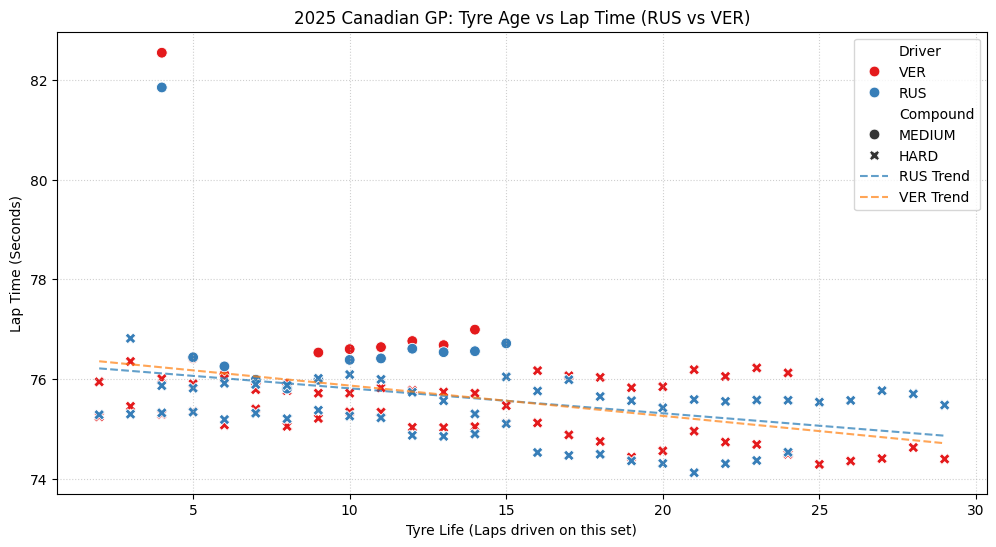

In [1]:
import fastf1 as ff1
import pandas as pd #데이터 분석
import numpy as np #수치 계산
import matplotlib.pyplot as plt #데이터 시각화
import seaborn as sns #고급 시각화

# 1. FastF1 캐시 설정 및 데이터 로드
ff1.Cache.enable_cache('f1_cache')

print("🏎️ 2025 캐나다 그랑프리 레이스 데이터를 로드 중입니다...")
session = ff1.get_session(2025, 'Canada', 'R')
session.load()

# 2. 전체 랩 데이터 추출 및 기본 정제
laps = session.laps

# 세이프티 카(SC), 버추얼 세이프티 카(VSC), 피트스톱 랩 등 
# 타이어 마모와 상관없이 랩타임이 튀는 '아웃라이어'를 제거하기 위한 필터링
# 보통 정상 랩타임의 107% 이내이거나 PitOut/PitIn이 없는 랩을 클린 랩으로 봅니다.
clean_laps = laps.pick_wo_box()
clean_laps = clean_laps[clean_laps['LapTime'].notna()]

# LapTime을 초(seconds) 단위로 변환
clean_laps['LapTimeSec'] = clean_laps['LapTime'].dt.total_seconds()

# 3. 조지 러셀(RUS)과 주요 경쟁 드라이버 데이터 필터링
# 비교를 위해 당시 상위권이었던 VER(페르스타펜)이나 LEC(르클레르)를 함께 추출합니다.
target_drivers = ['RUS', 'VER'] 
df_analysis = clean_laps[clean_laps['Driver'].isin(target_drivers)].copy()

# 4. 간단한 스틴트(Stint) 정보 확인
print("\n📊 드라이버별 타이어 스틴트 정보:")
for driver in target_drivers:
    driver_laps = df_analysis[df_analysis['Driver'] == driver]
    stints = driver_laps['Stint'].unique()
    print(f"\n[{driver}]")
    for stint in stints:
        stint_data = driver_laps[driver_laps['Stint'] == stint]
        compound = stint_data['Compound'].iloc[0]
        max_age = stint_data['TyreLife'].max()
        print(f" - Stint {stint}: Compound={compound}, Max Tyre Age={max_age} laps")

# 5. 타이어 마모도(Degradation) 시각화
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_analysis, 
    x='TyreLife', 
    y='LapTimeSec', 
    hue='Driver', 
    style='Compound',
    palette='Set1',
    s=60
)

# 마모 추세를 보기 위한 회귀선 추가 (간단한 선형 추세)
for driver in target_drivers:
    driver_data = df_analysis[df_analysis['Driver'] == driver]
    if not driver_data.empty:
        z = np.polyfit(driver_data['TyreLife'], driver_data['LapTimeSec'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(driver_data['TyreLife'].min(), driver_data['TyreLife'].max(), 100)
        plt.plot(x_range, p(x_range), linestyle='--', alpha=0.7, label=f'{driver} Trend')

plt.title('2025 Canadian GP: Tyre Age vs Lap Time (RUS vs VER)')
plt.xlabel('Tyre Life (Laps driven on this set)')
plt.ylabel('Lap Time (Seconds)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()